<a href="https://colab.research.google.com/github/falyseck/Math_ML_Formative3/blob/main/Probability_Distribution_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Loading the Iris dataset directly from the web
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)

# Selection of two numeric columns
x_col = "sepal_length"
y_col = "sepal_width"

data = df[[x_col, y_col]]
print(data.head())


   sepal_length  sepal_width
0           5.1          3.5
1           4.9          3.0
2           4.7          3.2
3           4.6          3.1
4           5.0          3.6


In [ ]:
import numpy as np

# Compute mean and std for both variables
mu_x = np.mean(data[x_col])
mu_y = np.mean(data[y_col])
sigma_x = np.std(data[x_col])
sigma_y = np.std(data[y_col])

# Compute correlation
rho = np.corrcoef(data[x_col], data[y_col])[0, 1]

# Define function for the bivariate normal PDF
def bivariate_normal_pdf(x, y, mu_x, mu_y, sigma_x, sigma_y, rho):
    coeff = 1 / (2 * np.pi * sigma_x * sigma_y * np.sqrt(1 - rho**2))
    exponent = -1 / (2 * (1 - rho**2)) * (
        ((x - mu_x)**2 / sigma_x**2) +
        ((y - mu_y)**2 / sigma_y**2) -
        (2 * rho * (x - mu_x) * (y - mu_y) / (sigma_x * sigma_y))
    )
    return coeff * np.exp(exponent)

# Compute PDF for each data point
pdf_values = bivariate_normal_pdf(
    data[x_col], data[y_col],
    mu_x, mu_y, sigma_x, sigma_y, rho
)

data["pdf"] = pdf_values
print(data.head())


   sepal_length  sepal_width       pdf
0           5.1          3.5  0.195247
1           4.9          3.0  0.224392
2           4.7          3.2  0.168867
3           4.6          3.1  0.143258
4           5.0          3.6  0.138961


/tmp/ipython-input-1915934490.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["pdf"] = pdf_values


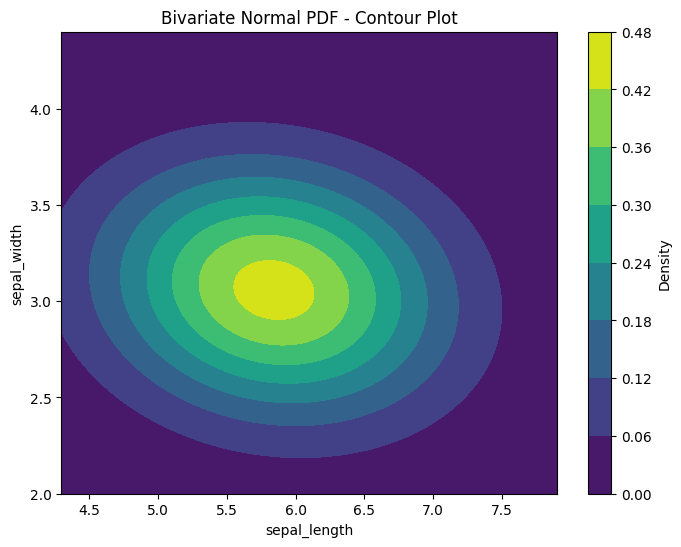

In [ ]:
import matplotlib.pyplot as plt

# Create a grid over the feature space
x = np.linspace(data[x_col].min(), data[x_col].max(), 100)
y = np.linspace(data[y_col].min(), data[y_col].max(), 100)
X, Y = np.meshgrid(x, y)

# Compute PDF values for the grid
Z = bivariate_normal_pdf(X, Y, mu_x, mu_y, sigma_x, sigma_y, rho)

# Plot contour
plt.figure(figsize=(8,6))
plt.contourf(X, Y, Z, cmap='viridis')
plt.xlabel(x_col)
plt.ylabel(y_col)
plt.title("Bivariate Normal PDF - Contour Plot")
plt.colorbar(label='Density')
plt.show()


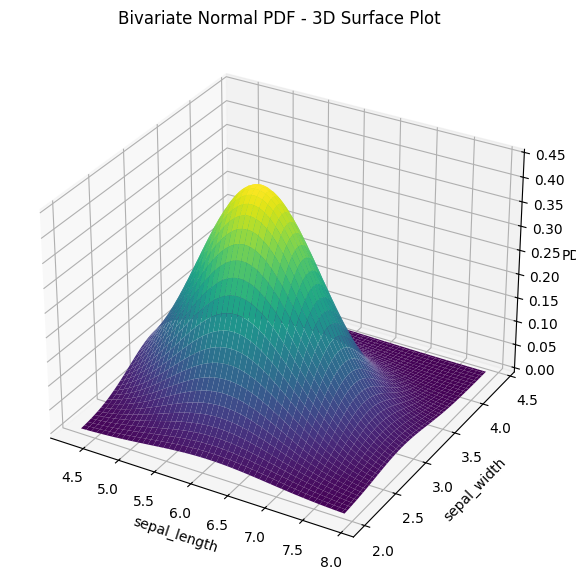

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z, cmap='viridis')
ax.set_xlabel(x_col)
ax.set_ylabel(y_col)
ax.set_zlabel('PDF')
ax.set_title("Bivariate Normal PDF - 3D Surface Plot")

plt.show()


**Analysis and Summary**

The probability density function (PDF) values represent how likely each
(
𝑥
,
𝑦
)
(x,y) point is under the bivariate normal distribution.
Points located near the mean (the center of the ellipse) have higher PDF values, indicating a higher probability density, while points farther from the mean have lower PDF values.

The contour plot illustrates the spread of the data density in two dimensions.
The elliptical contours suggest a correlation between the two variables — the more elongated the ellipse, the stronger the correlation.

The 3D surface plot provides a visual representation of the joint probability surface.
It shows the characteristic bell-shaped structure of a normal distribution, where the peak occurs at the mean and gradually decreases outward.

In comparison to other probability distributions:

The normal distribution is symmetric and bell-shaped.

The uniform distribution is flat, indicating equal probability across its range.

The exponential distribution is skewed to the right, with a high probability density near zero that decays rapidly.

Overall, the results confirm that the selected data variables follow a pattern consistent with a bivariate normal distribution, making this model suitable for their joint behavior.